# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


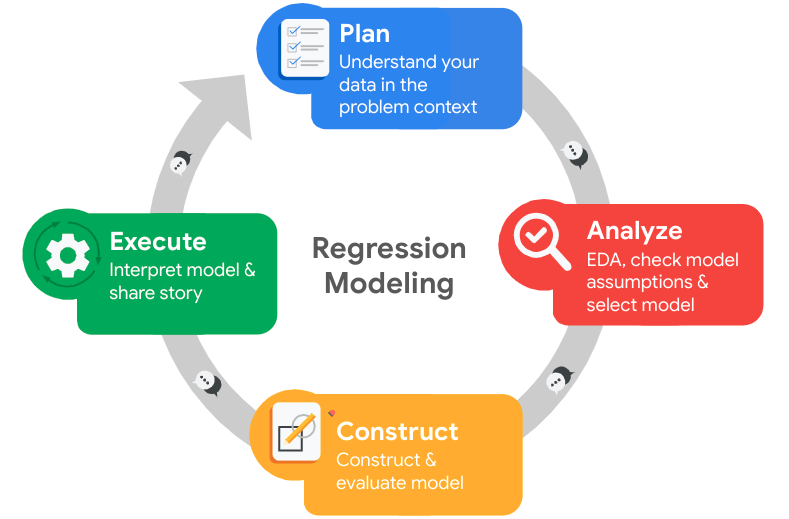

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




# Introduction
In this scenario, we will be anayzling a dataset that consists of 15,000 observation and 10 columns provided by the HR department. Our main objective is find a suitable model and train a model to predict whether employees will stay in the company. 

# Variables
As our objective is to determine whether a employee stays in the company, our outcome variables is `left`.(1 = left, 0 = stay) Our initial features will be `satisfaction_level`,`last_evaluation`,`number_project`,`average_monthly_hours`,`time_spend_company`,`Work_accident`,`promotion_last_5years`,`Department`,`salary`. On initial inspection, my suspisions is that sastification level is more likely to contribute to the outcome variables, however, more inspection is required in our EDA. 

# Plan
We will first proceed via EDA where we will clean, explore and validate our dataset. Since the outcome variable we are interested is binary, we will proceed via classifcation method. Some methods that available for use will be Logisitic Regression, Naive Bayes, XGBoost and Random Forest Classifier. We will split our dataset into an 80% training set and a 20% testing set. To prevent data leakage and optimize hyperparameter tuning, the 20% test dataset will remain completely untouched until the final evaluation. On the 80% training data, we will implement 5-fold Cross-Validation to train and tune our four candidate models (Logistic Regression, Naive Bayes, XGBoost, and Random Forest). The model that achieves the highest average F1-score across the cross-validation folds will be selected as our champion model, which will then be evaluated against the final test set. We will decide whether to strafity on y if an imbalance in outcome variable, `left` exist. This will be determine in our EDA process. We will use a metrics to determine which model will be our champion model. This model will be tested with our test dataset to determine its metrics. 

# Approach 
As each model has its own asssumption and criteria, each model will have its own dataset that engineered specifically based on the model. During custom modelling, we will first perform feature engineering which involves three steps, selection, transformation and creation. We will first create new features aggregated from the original features. Other transformation such as encoding, standardizing will also be done based on each model. We first establish a baseline for each model. With a reference, we start to opitimize each model hyperparameter. 

# Metrics
False Positve - Predicts employee will leave, but they actually stay
False Negative  - Predicts employee will stay, but they actually leave
There will be two key metrics in determining which model to choose - type 1 error (False Positive Rate) and type 2 error (False Negative Rate). This will be tested via Precision and Recall (True Positive Rate) respectiively.
In this context, we are interested in finding the reasons why employees.Furthermore, we have to account for the cost and resources to interview,nurture and train candidates. As such, it will be better to have a good balance between recall and precision, such that we do waste retention resources on employees who are not going to quit and investigate the reasons behind the high turnover rate. Thus, f1, which measure both precision and recall score will be our main metrics in this situation. 

# Ethical Context
While there is no issues, salary tends to be a sensitive topic in the company. Additional measures are required to safeguard this data. This include who to consult regarding the data, no data leakage, or additional lock/password to protect sensitive data. 

 


## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [1]:
# Import packages
### YOUR CODE HERE ### 
# we will first import packages for data manipulation and data visulization for EDA

import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt


### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
### YOUR CODE HERE ###
df0.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [3]:
# Gather basic information about the data
### YOUR CODE HERE ###
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
df0.shape

(14999, 10)

It seems like there is an error in the information reported to us, it was noted there was 15,000 observation. However, we only recieve 14,999. Since it is a small amount, it most likely won't affect our model training. However, it is still best to update our stakeholders regarding it. 

### Gather descriptive statistics about the data

In [5]:
# Gather descriptive statistics about the data
### YOUR CODE HERE ###
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


From that data, we can see that `satisfaction_level`, `last_evalution,left`, `promotion_last_5years` all ranges from 0 to 1, and looking at the mean and median gives us a good sense of how skew the dsitribution is. The number of projects is relatively low given the average mean year spend is about 3 years. This could account for the lack of motivation or meaning in employees.  We shall look at the distribution of `left`


In [6]:
df0['left'].value_counts()

0    11428
1     3571
Name: left, dtype: int64

The data is highly umbalanced, it will be important to straify on y when spilting the dataset to ensure the proportion of training/test data

### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [7]:
# Display all column names
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [8]:
# Rename columns as needed
### YOUR CODE HERE ###
df0 = df0.rename(columns={"number_project": "projects", "average_montly_hours": "monthly_hours", 'time_spend_company': 'tenure', 
                   'Work_accident': 'accident', 'Department': 'department'})


# Display all column names after the update
### YOUR CODE HERE ###
df0.columns


Index(['satisfaction_level', 'last_evaluation', 'projects', 'monthly_hours',
       'tenure', 'accident', 'left', 'promotion_last_5years', 'department',
       'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [9]:
# Check for missing values
### YOUR CODE HERE ###
df0.isna().sum(axis=0)

satisfaction_level       0
last_evaluation          0
projects                 0
monthly_hours            0
tenure                   0
accident                 0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [10]:
# Check for duplicates
### YOUR CODE HERE ###
df0.duplicated().sum()

3008

In [11]:
# Inspect some rows containing duplicates as needed
### YOUR CODE HERE ###
df0[df0.duplicated()]['left'].value_counts(normalize=True)

1    0.525266
0    0.474734
Name: left, dtype: float64

In [12]:
# Drop duplicates and save resulting dataframe in a new variable as needed
### YOUR CODE HERE ###
# we will drop duplicates as there is no information in employer ID, making it difficult to diff whether it is logging error or geniune repetitions in data
# This is also to prevent data leakage when we work cross-validation so that our model does not overfit and memorize the observation. 
df1= df0.drop_duplicates(keep = 'first').reset_index(drop =True)


# Display first few rows of new dataframe as needed
### YOUR CODE HERE ###
df1.head()

,satisfaction_level,last_evaluation,projects,monthly_hours,tenure,accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

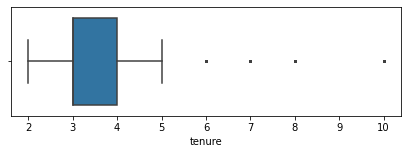

In [13]:
# Create a boxplot to visualize distribution of `tenure` and detect any outliers
### YOUR CODE HERE ###
plt.figure(figsize = (7,2))
sns.boxplot(x = "tenure", fliersize = 1, data = df1)

In [14]:
# Determine the number of rows containing outliers
### YOUR CODE HERE ###
#we will first create a function that looks for outlier to reduce code repetition 
def find_outliers(data,feature):
    '''
    Documentation: This function is mainly use to find outliers in a feature
    Parameter: 
    data - > a DataFrame classing consisting of rows and columns
    feature - > a string that consisting the name of the feature you are interested. 

    '''
    per25 = data[feature].quantile(0.25)
    per75 = data[feature].quantile(0.75)
    
    IQR = per75 - per25
    
    highlimit = per75 +1.5 * IQR
    lowlimit = per25 - 1.5 * IQR
    
    outliers = data[(data[feature]> highlimit) | (data[feature] < lowlimit) ]
    
    return (len(outliers), outliers)


In [15]:
find_outliers(df1, 'tenure')

(824,
        satisfaction_level  last_evaluation  projects  monthly_hours  tenure  \
 1                    0.80             0.86         5            262       6   
 17                   0.78             0.99         4            255       6   
 34                   0.84             0.87         4            246       6   
 47                   0.57             0.70         3            273       6   
 67                   0.90             0.98         4            264       6   
 ...                   ...              ...       ...            ...     ...   
 11985                0.22             0.94         3            193      10   
 11986                0.90             0.55         3            259      10   
 11987                0.74             0.95         5            266      10   
 11988                0.85             0.54         3            185      10   
 11989                0.33             0.65         3            172      10   
 
        accident  left  promotio

we shall also inspect monthly_hours and projects 

In [16]:
find_outliers(df1, 'monthly_hours')

(0,
 Empty DataFrame
 Columns: [satisfaction_level, last_evaluation, projects, monthly_hours, tenure, accident, left, promotion_last_5years, department, salary]
 Index: [])

In [17]:
find_outliers(df1, 'projects')

(0,
 Empty DataFrame
 Columns: [satisfaction_level, last_evaluation, projects, monthly_hours, tenure, accident, left, promotion_last_5years, department, salary]
 Index: [])

# Bonus
While the workbook did not ask to inspect all features for outliers (since I assume they alr know the answer), it is still best practice to check for outliers in all features. We will create a function to to create a dictionary for us. 

In [18]:
def find_all_outliers(data,features):
    '''
    Documentation: This function is mainly use to find outliers in a feature
    Parameter: 
    data - > a DataFrame classing consisting of rows and columns
    features - > a list of string that consisting the name of continuous feature(s) you are interested. 

    '''
    out = {}
    for feat in features:
        
        per25 = data[feat].quantile(0.25)
        per75 = data[feat].quantile(0.75)

        IQR = per75 - per25

        highlimit = per75 +1.5 * IQR
        lowlimit = per25 - 1.5 * IQR

        outliers = data[(data[feat]> highlimit) | (data[feat] < lowlimit)]
        out[feat] = (len(outliers), outliers)
    
    return out

In [19]:
find_all_outliers(df1, ["satisfaction_level", "last_evaluation",
                        "projects", "monthly_hours", "tenure"])

{'satisfaction_level': (0,
  Empty DataFrame
  Columns: [satisfaction_level, last_evaluation, projects, monthly_hours, tenure, accident, left, promotion_last_5years, department, salary]
  Index: []),
 'last_evaluation': (0,
  Empty DataFrame
  Columns: [satisfaction_level, last_evaluation, projects, monthly_hours, tenure, accident, left, promotion_last_5years, department, salary]
  Index: []),
 'projects': (0,
  Empty DataFrame
  Columns: [satisfaction_level, last_evaluation, projects, monthly_hours, tenure, accident, left, promotion_last_5years, department, salary]
  Index: []),
 'monthly_hours': (0,
  Empty DataFrame
  Columns: [satisfaction_level, last_evaluation, projects, monthly_hours, tenure, accident, left, promotion_last_5years, department, salary]
  Index: []),
 'tenure': (824,
         satisfaction_level  last_evaluation  projects  monthly_hours  tenure  \
  1                    0.80             0.86         5            262       6   
  17                   0.78            

Expected, only 'tenure' shows outliers. This also shows that there is quite a number of loyal employers who stay in the company comapred to the majority who leave (as seen in the boxplot). A more in depth understanding of the situtation could also be investigating the outliers( are they founders or higher executive). We will be more interested in finding employees who stay and the reasons why they decided to continue serving the company. 

Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




[Double-click to enter your responses here.]

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [20]:
# Get numbers of people who left vs. stayed
### YOUR CODE HERE ###

# Get percentages of people who left vs. stayed
### YOUR CODE HERE ###
df1['left'].value_counts(normalize = True)
### previous portion


0    0.833959
1    0.166041
Name: left, dtype: float64

### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

# Initial Inspection
We will first examine the bi-relationship between each feature and the outcome variable. This gives us a clearer picture of the dataset before delving deeper into the r/s. 

## Continous Variable
For cont. feature, we will analyze with a boxplot, with a basis on the outcome variable. To avoid boxplot from hding bimodal or multimodal distribution, we will add a overlapped Kernel Density Estimate split by outcome variable. This gives a better understanding of the data. 

## Binary Categorical Variable
For binary categorical variable, we will analyze based on porportions contigency table with odds ratio. This shows the relative, making it easy for us to interpret it. 

## Other Categorical Variable
For mulit categorical variable, contigenct might complicate the data. In this case, we will use a bar plot to see the difference in the category with respect to the outcome variable. 

Note:While projects might seem tempting to place it as cont. vars, it is more of discrete varirable. Thus, it will be better to include it under multi categorical variables. 

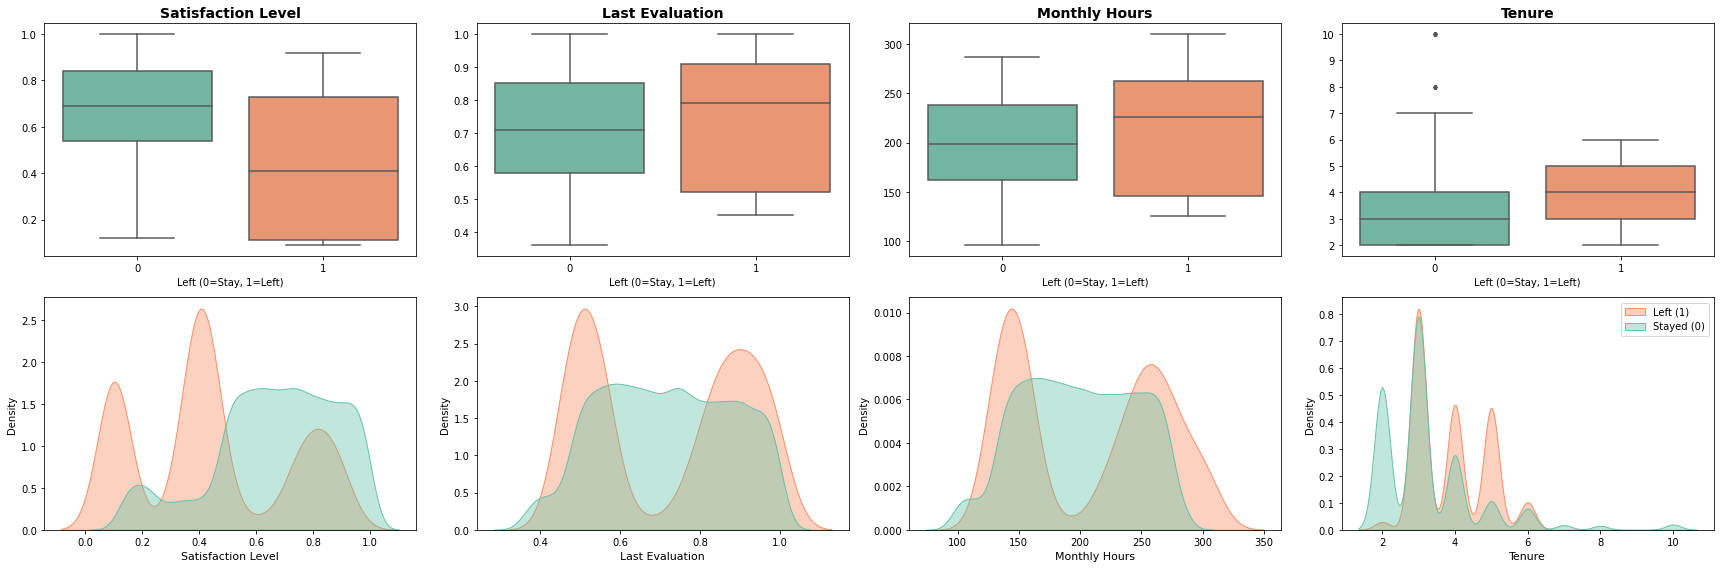

In [21]:
# Cont. Vars

continuous_features = ['satisfaction_level', 'last_evaluation', 'monthly_hours', 'tenure']

# Set up a 2-row, 4-column grid (8 plots total)
fig, axes = plt.subplots(2, 4, figsize=(24, 8))

for i, feature in enumerate(continuous_features):
    sns.boxplot(
        data=df1, 
        x='left', 
        y=feature, 
        ax=axes[0, i], 
        palette='Set2', 
        fliersize=3
    )
    axes[0, i].set_title(f'{feature.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    axes[0, i].set_xlabel('Left (0=Stay, 1=Left)', fontsize=10)
    axes[0, i].set_ylabel('')
    
    sns.kdeplot(
        data=df1, 
        x=feature, 
        hue='left', 
        palette=['#66c2a5', '#fc8d62'], 
        fill=True, 
        common_norm=False, 
        ax=axes[1, i],
        alpha=0.4
    )
    axes[1, i].set_xlabel(feature.replace("_", " ").title(), fontsize=11)
    axes[1, i].set_ylabel('Density')
    
    # Clean up the legends on the bottom row so they aren't cluttered
    # Only keep the legend on the very last plot to save space
    if i != 3: 
        axes[1, i].get_legend().remove()
    else:
        axes[1, i].legend(['Left (1)', 'Stayed (0)'], loc='upper right')

plt.tight_layout()
plt.show()




In [22]:
#Binary Categorical Variable
from scipy.stats import fisher_exact

ct_accident = pd.crosstab(df1['accident'], df1['left']) 
ct_promotion = pd.crosstab(df1['promotion_last_5years'], df1['left'])
odds_ratio_acc, p_value_acc = fisher_exact(ct_accident)
odds_ratio_pro, p_value_pro = fisher_exact(ct_promotion)
print("Accident")
print(ct_accident)
print(odds_ratio_acc)
print()
print("Promotion in the last 5 years")
print(ct_promotion)
print(odds_ratio_pro)

Accident
left         0     1
accident            
0         8255  1886
1         1745   105
0.26337179093729396

Promotion in the last 5 years
left                      0     1
promotion_last_5years            
0                      9805  1983
1                       195     8
0.20285245096137683


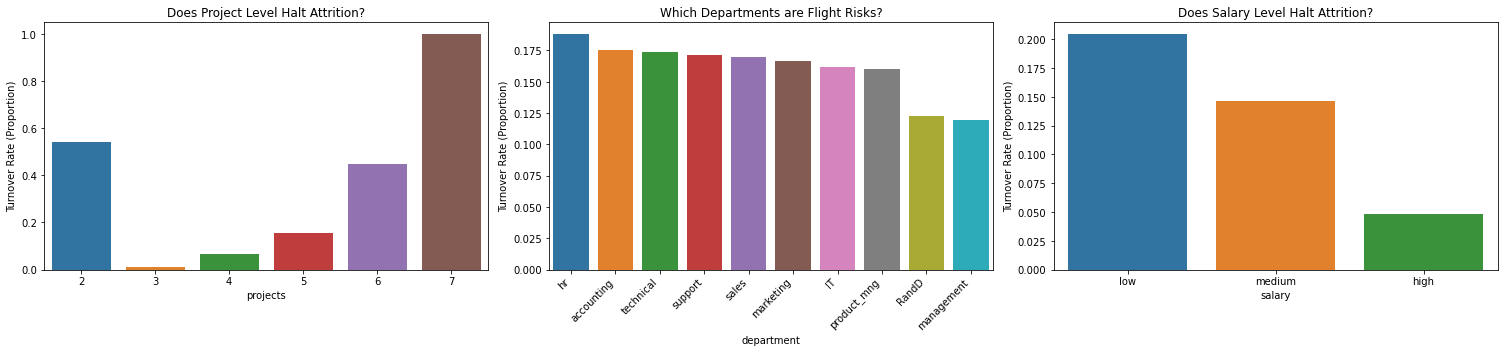

In [23]:
#Multiple Cat. Var

fig, ax = plt.subplots(1, 3, figsize=(21, 5))

# Turnover rate by Projects Tier
sns.barplot(data=df1, x='projects', y='left', order=[2, 3, 4, 5, 6, 7], ax=ax[0], ci =None)
ax[0].set_ylabel('Turnover Rate (Proportion)')
ax[0].set_title('Does Project Level Halt Attrition?')

# Turnover rate by Department (sorted from highest risk to lowest)
dept_order = df1.groupby('department')['left'].mean().sort_values(ascending=False).index
sns.barplot(data=df1, x='department', y='left', order=dept_order, ax=ax[1], ci = None)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha='right')
ax[1].set_ylabel('Turnover Rate (Proportion)')
ax[1].set_title('Which Departments are Flight Risks?')

# Turnover rate by Salary Tier
sns.barplot(data=df1, x='salary', y='left', order=['low', 'medium', 'high'], ax=ax[2], ci =None)
ax[2].set_ylabel('Turnover Rate (Proportion)')
ax[2].set_title('Does Salary Level Halt Attrition?')

plt.tight_layout()
plt.show()

In [24]:
df1.groupby('department')['left'].mean().sort_values(ascending=False)


department
hr             0.188020
accounting     0.175523
technical      0.173797
support        0.171334
sales          0.169805
marketing      0.166419
IT             0.161885
product_mng    0.160350
RandD          0.122478
management     0.119266
Name: left, dtype: float64

# Initial anaylsis of each feature vairable with respect to the outcome variable
We are mainly interested in the positive outcome vairable ( Y = 1 -> Left). 
For all continuous vairable except, there are differences in the median wrt outcome variable. However, last_evaluation and monthly hours have a slightly weak associations.  

## Satisfaction level
We notice that there are are larger proportion of employees that left has lower satisfaction rate. The diagram reflects trimodal distribution with two distinct groups that are highly dissatified (most peak at around 0.4 ,followed by 0.2). Crucially, there is another peak around 0.8 with larger variance. This indication that turnover are not only due to low happiness. A hypothesisis due to new oppurtunities or work accident that forces that them to leave. This is worth investigating by looking at the relationship of satisfaction and last_evalution or working hours wrt to outcome variable. 

## Last Evaluation
For clarity, last evaluation evaluates employess latest performance. The perfomance evaluation metrics for departing employees confirms a bimodal distribution with 2 peaks around 0.5 and 0.9. This could be due to low motuvation or high achiever job hopping for better opurtunities. This supports our hypothesis based on satisfaction level. What is once again worth noting is that the difference in spead in each peaks. 

## Monthly Hours
Once again, monthly hours mirros the bi-modal distribution seen in evaluations( peaks at low and high working hours). This suggest that employees are leaving from two strucural extremes. Underutilized workers are working under 150hrs per month while overworked indivs are exceeding 250 hours per month. This suggest an underlying issues where resources are not properly allocated.  It might be better to investigate the relationship between the amount of work given and working hours. 

## Tenure 
For tenure, we notice that there is around the same density of people who choose to stay and leave, with lesser leaving as the number of years increases. A better way to deal with tenure would to split tenure into a binary category of high and low risk. Tenure years that is around 3 to 6 are denoted as high risk with 1, while the rest are 0. 

## accident
From the contigency table, we will expect that accident will have a positive correlation with outcome variable. However,we notice that work accident acts as a strong protective factor against turnover.  Employees who had an accident are roughly 74% less likely to leave. This counterinuitive findings suggest that it could be due to health insurance and benefits provided for employees. Another thing to note might be that employees might still be considered employed during injury. They were allowed to rest and recuperate compared to others who might be overworked. This is something to be consulted with the HR department regarding their work policies. 

## Promotion in the last 5 years
We notice a 0.20 odd ratio. This suggest that employees who did recieve a promotion has a 80% reduction in their chances of leaving compared to those who were not promoted. This suggest an underlying issue due to career stagnation that could affect their work motivation. One possible relationship is with tenure, last_evaluations and monthly_hours/projects.

Note: due to how pandas placed the 0 and 1, we usually compared the the bottom right agaisnt the top left. consider contigency table  comprising A and B(row 1), C and D(row 2) respectively. (row wise arrangement). OR = (a/b)/(c/d) = ad/bc.  

## Projects
We notice a high turnover rate for those who did 6-7 projects and those who only did 2 projects. This could be attibuted to low motivation from work or high workload as mentioned previously. It will be more important to guage the workload compared to the working hours to have a better guage. 

## Deparments
Overall, we notice that turnover rate is around the same across all departments have around the same turnover rate. There is two take towards this finding. One is that this could potentially means that the bad working conditions are cultural and systemic throughout the company. However, another take on this is that the impact is decentralized. Thus, it is crucial to contain the impact and increase the retention rate. 

## Salary
We notice that salary has a negative correlation with number of people who leave. However, it might be better to stratify this result with categorical variable such as tenure, number of projects and monthly hours. 

# Further Steps 

In the next section, we will be analyzing the following relationship to investigate further:
 - `satisfaction_level` and `projects` wrt to `left`
 - `satisfaction_level` and `monthly_hours` wrt to `left`
 - `satisfaction_level` and `last_evaluation` wrt to `left`
 - `monthly_hours` and `last_evaluation` wrt to `left`
 - `projects` and `monthly_hours` wrt to `left`
 - `projects` and `left` 
 - `monthly_hours` and `promotion_last_5years`
 - correlation heat map
 - pairwise plot 
 

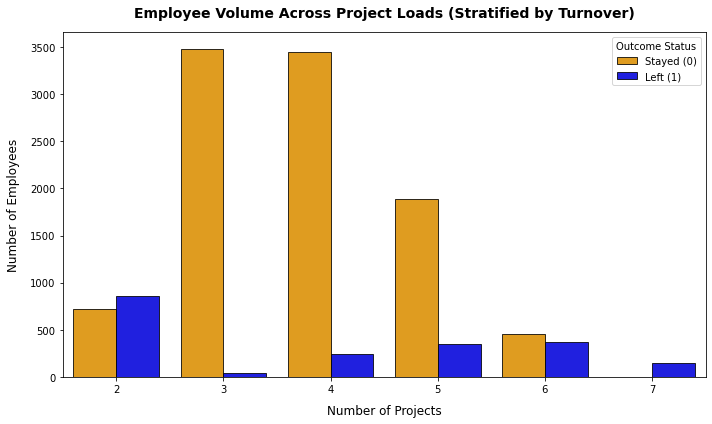

In [25]:
#we will first check the actual count of employeer stratified with left. 

fig, ax = plt.subplots(figsize=(10, 6))


sns.countplot(
    data=df1,
    x='projects',
    hue='left',
    order=sorted(df1['projects'].unique()),
    palette=['orange', 'blue'],  # Maintaining your exact color consistency
    edgecolor='black',
    linewidth=0.8,
    ax=ax
)

ax.set_title('Employee Volume Across Project Loads (Stratified by Turnover)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Projects', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Employees', fontsize=12, labelpad=10)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Stayed (0)', 'Left (1)'], title='Outcome Status', loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

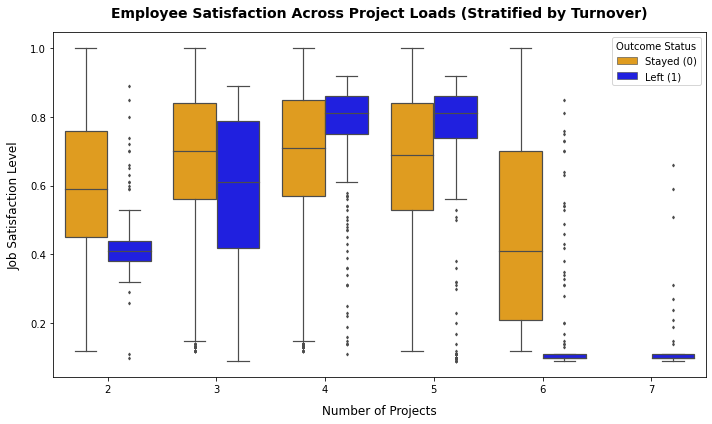

In [26]:
# next we will obs the r/s between satisfaction_level and projects wrt to left
# with two cat var and cont var, a multi boxplot will crucial to analyze it. 



fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1,
    x='projects',
    y='satisfaction_level',
    hue='left',
    palette=['orange', 'blue'], 
    fliersize=2,                    
    linewidth=1.2,
    ax=ax
)

ax.set_title('Employee Satisfaction Across Project Loads (Stratified by Turnover)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Projects', fontsize=12, labelpad=10)
ax.set_ylabel('Job Satisfaction Level', fontsize=12, labelpad=10)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Stayed (0)', 'Left (1)'], title='Outcome Status', loc='top right', frameon=True)

plt.tight_layout()
plt.show()

From the 2 plot above, we can notice a few things
1. We observe that everyone who did 7 projects left. Most employees' Satisfaction level are lower than 0.1 in that category, with a few outliers that were still satisfied with the workload. 
2. For extreme cases such 2,6,7, there is a signficant difference between the median of satisfaction level between those who stay and leave, while the rest is quite comparable. 
3. We observe that 3 projects seems to be the most optimal workload. This is the only cateogry where the median satisfaction level is higher for those who stayed and the IQR overlaps significantly. 
4. 3 projects also results in the number of people leaving, supporting point 3
5. Generally, number of projects does not seem to be the main criteria for people leaving. Employees who did mainly 2, 6, 7 are outliers compared to the general population. In general, high workload and low motivation seems to be one of the contributing factors. 

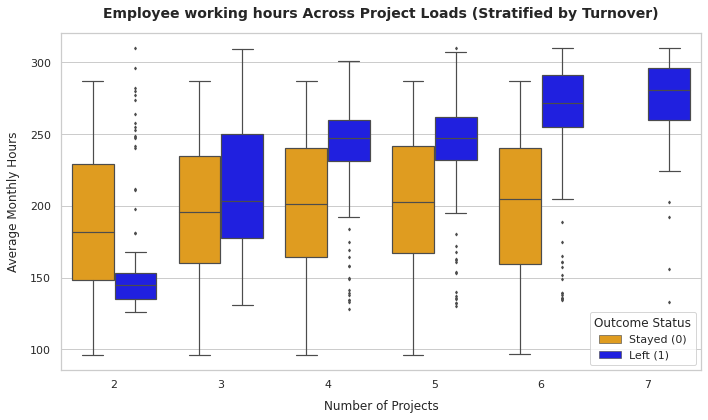

In [27]:
# As such, it might be better to investigate the r/s between number of projects and working hours to determine if it is correlated.
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1,
    x='projects',
    y='monthly_hours',
    hue='left',
    palette=['orange', 'blue'], 
    fliersize=2,                    
    linewidth=1.2,
    ax=ax
)

ax.set_title('Employee working hours Across Project Loads (Stratified by Turnover)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Projects', fontsize=12, labelpad=10)
ax.set_ylabel('Average Monthly Hours', fontsize=12, labelpad=10)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Stayed (0)', 'Left (1)'], title='Outcome Status', loc='top right', frameon=True)

plt.tight_layout()
plt.show()

From the plot above, we generally notice the number of working hours increases as project loads increase. However, there is some interesing points to take note:
1. For 2 projects, the median working hours for those who left is lower than those stayed. Some other reasons could be they have other issues such as family, or other commitments. They are aware of possible notice or retrenchment and are thus assigned lower working hours. They could be abusing MC also, resulting in the low working hours. 
2. The median working hours for those who stayed are generally the same across all number of proejcts. Whereas, the median working hours for those who leavee increases. This suggests the possinle unequal distribution where some groups might be working on longer projects or there might be free loader in some groups. 
3. Employee who did 6 project and left have the same median working hours compared to those who did 7 projects. Once again, possible reasons is unequal distribution of work or length of projects. 

A better understanding will include average number of projects over tenure and working hours to see if they are overworked. Another features that might give more insights is the length of total projects. This is because some projects might take longer time than others and using discrete values might not accurately represent the workload. 

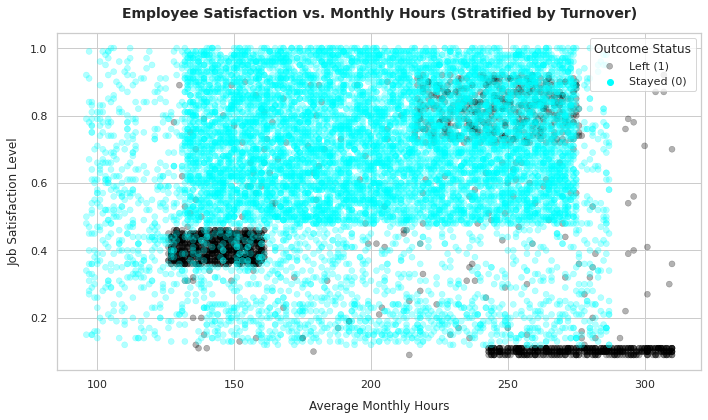

In [28]:
# we will now move on to investigate number of working hours against satisfaction wrt to left 

# scatterplot of satisfaction_level against monthly_hours stratified by left

plt.figure(figsize=(10, 6))

# Using alpha=0.5 helps deal with overplotting (dense areas of data points)
sns.scatterplot(
    data=df1,
    x="monthly_hours",
    y="satisfaction_level",
    hue="left",
    hue_order = [0,1],
    palette=["cyan", "black"],
    alpha=0.3
    ,
    edgecolor=None,
)

plt.title(
    "Employee Satisfaction vs. Monthly Hours (Stratified by Turnover)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Average Monthly Hours", fontsize=12, labelpad=10)
plt.ylabel("Job Satisfaction Level", fontsize=12, labelpad=10)

plt.legend(title="Outcome Status", labels=[ "Left (1)","Stayed (0)"], loc="best")

plt.tight_layout()
plt.show()


In general, we notice that the that the data is quite spread with no correlation. 
1. People who work over 300 hours gernerally have lower evaluation 
2. There seems to be some group of cluster where the satisfaction level is cluttered around a range of value. 
3. People who leave are group into 3 group, low working hour with low satisfaction level, high working hours with high satisfaction and very high working hours with low satisfaction. 

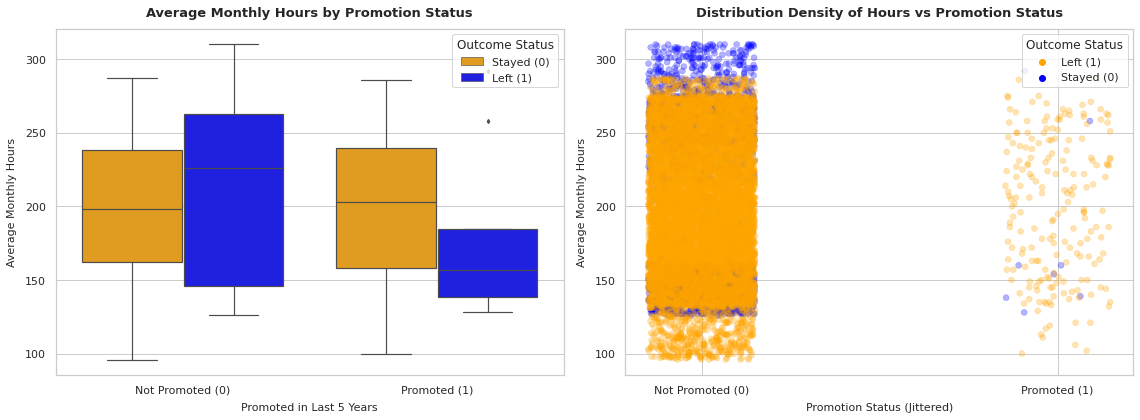

In [29]:
# we will know compare monthly hours with promotion in last 5 years wrt to left. Scatterplot is used with boxplot so that we can see the actual plots 

df1_plot = df1.copy()
df1_plot["promotion_jittered"] = df1_plot[
    "promotion_last_5years"
] + np.random.uniform(-0.15, 0.15, size=len(df1_plot))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.boxplot(
    data=df1_plot,
    x="promotion_last_5years",
    y="monthly_hours",
    hue="left",
    hue_order=[0, 1],
    palette=["orange", "blue"],
    linewidth=1.2,
    fliersize=3,
    ax=axes[0],
)

axes[0].set_title(
    "Average Monthly Hours by Promotion Status", fontsize=13, fontweight="bold", pad=12
)
axes[0].set_xlabel("Promoted in Last 5 Years", fontsize=11, labelpad=8)
axes[0].set_ylabel("Average Monthly Hours", fontsize=11, labelpad=8)
axes[0].set_xticklabels(["Not Promoted (0)", "Promoted (1)"])

handles0, labels0 = axes[0].get_legend_handles_labels()
axes[0].legend(
    handles0, ["Stayed (0)", "Left (1)"], title="Outcome Status", loc="upper right"
)


sns.scatterplot(
    data=df1_plot,
    x="promotion_jittered",
    y="monthly_hours",
    hue="left",
    hue_order=[0, 1],
    palette=["orange", "blue"],
    alpha=0.3,  
    edgecolor=None,
    ax=axes[1],
)

axes[1].set_title(
    "Distribution Density of Hours vs Promotion Status",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
axes[1].set_xlabel("Promotion Status (Jittered)", fontsize=11, labelpad=8)
axes[1].set_ylabel("Average Monthly Hours", fontsize=11, labelpad=8)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Not Promoted (0)", "Promoted (1)"])

handles1, labels1 = axes[1].get_legend_handles_labels()
axes[1].legend(
    handles1, [ "Left (1)","Stayed (0)"], title="Outcome Status", loc="upper right"
)

plt.tight_layout()
plt.show()


We notice something interesting. There seems be a small number of employees that are promoted in the last 5 years, This suggest that career progression in the company is not strong. Furthermore, people are promoted are more likely to stay. From our boxplot, we notice that people who are promoted, but those who leave are working very low hours of around 150. 

Another point to note that people who work very high hours eventually leaves the company. Furthermore, it points out that high working hours does not neccessarily lead to promotion. 

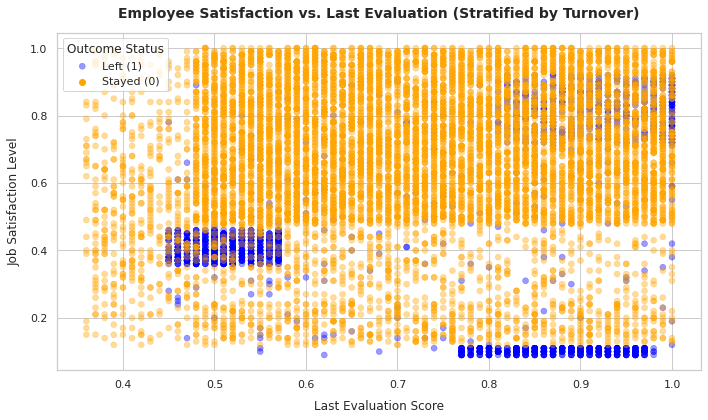

In [30]:
# we will now plot a scatgterplot of satisfaction level against last_evalution
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df1,
    x="last_evaluation",
    y="satisfaction_level",
    hue="left",
    hue_order=[0, 1],
    palette=["orange", "blue"],
    alpha=0.4,  
    edgecolor=None,
)

plt.title(
    "Employee Satisfaction vs. Last Evaluation (Stratified by Turnover)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Last Evaluation Score", fontsize=12, labelpad=10)
plt.ylabel("Job Satisfaction Level", fontsize=12, labelpad=10)


plt.legend(title="Outcome Status", labels=[ "Left (1)","Stayed (0)"],loc = 'best')

plt.tight_layout()
plt.show()

Something unique we observed is that there seems to ba a same pattern with satisfaction and monthly_hours. This might actually suggest that last_evaluation score and montlhy_hours are highly correlated. We shall proceed to add another plot of last evaluation against monthly_hours.

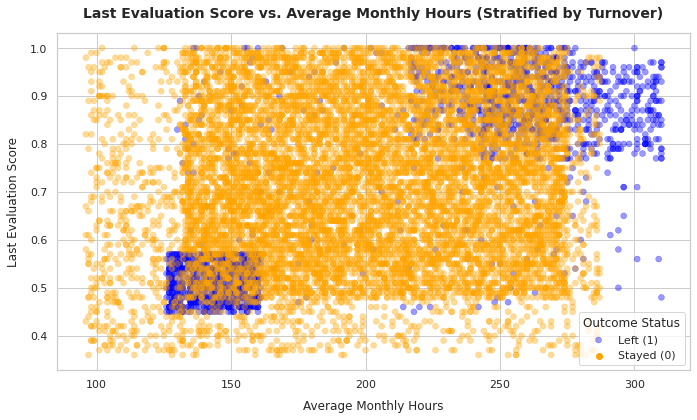

In [31]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df1,
    x="monthly_hours",
    y="last_evaluation",
    hue="left",
    hue_order=[0, 1],
    palette=["orange", "blue"],
    alpha=0.4,  
    edgecolor=None,
)

plt.title(
    "Last Evaluation Score vs. Average Monthly Hours (Stratified by Turnover)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Average Monthly Hours", fontsize=12, labelpad=10)
plt.ylabel("Last Evaluation Score", fontsize=12, labelpad=10)

plt.legend(title="Outcome Status", labels=[ "Left (1)", "Stayed (0)"], loc="best")

plt.tight_layout()
plt.show()

Interestingly, we notice two groups of employees who left. Those working less hours have a lower performance score, while those  overloading gernerally do well. This suggest the really bad working culture. 

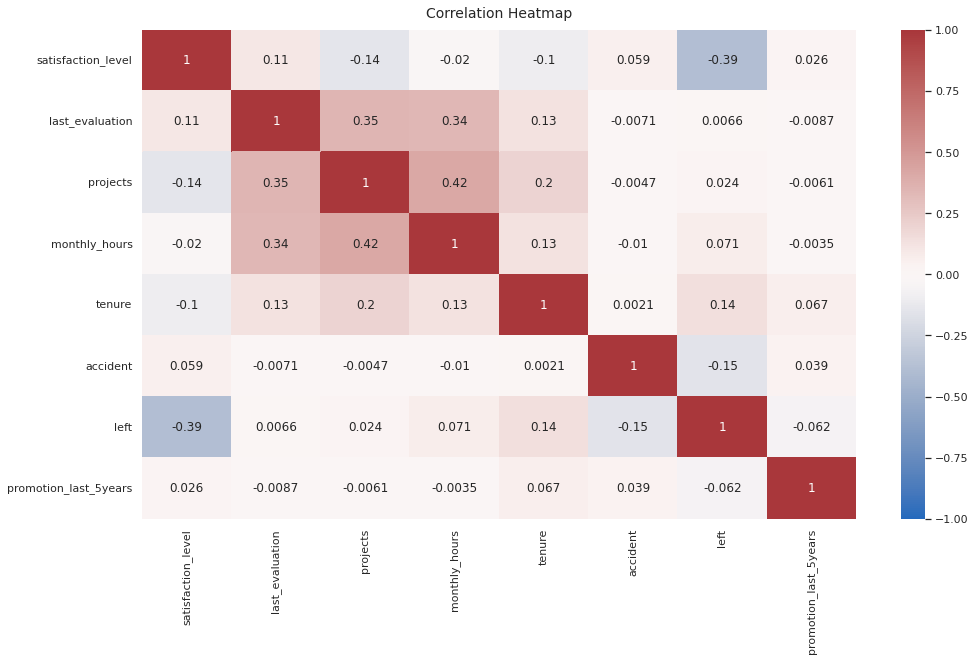

In [32]:
plt.figure(figsize=(16, 9))
heatmap = sns.heatmap(df0.corr(), vmin=-1, vmax=1, annot=True, cmap=sns.color_palette("vlag", as_cmap=True))
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12);

In gerneral, we notice a block where there exists high correlation. `last_evaluation`, `projects`and  `monthly_hours`  seems to be highly correlated to each other. We also noted that `satisfaction_level` are negatively correlated to `left` which is as expected. 

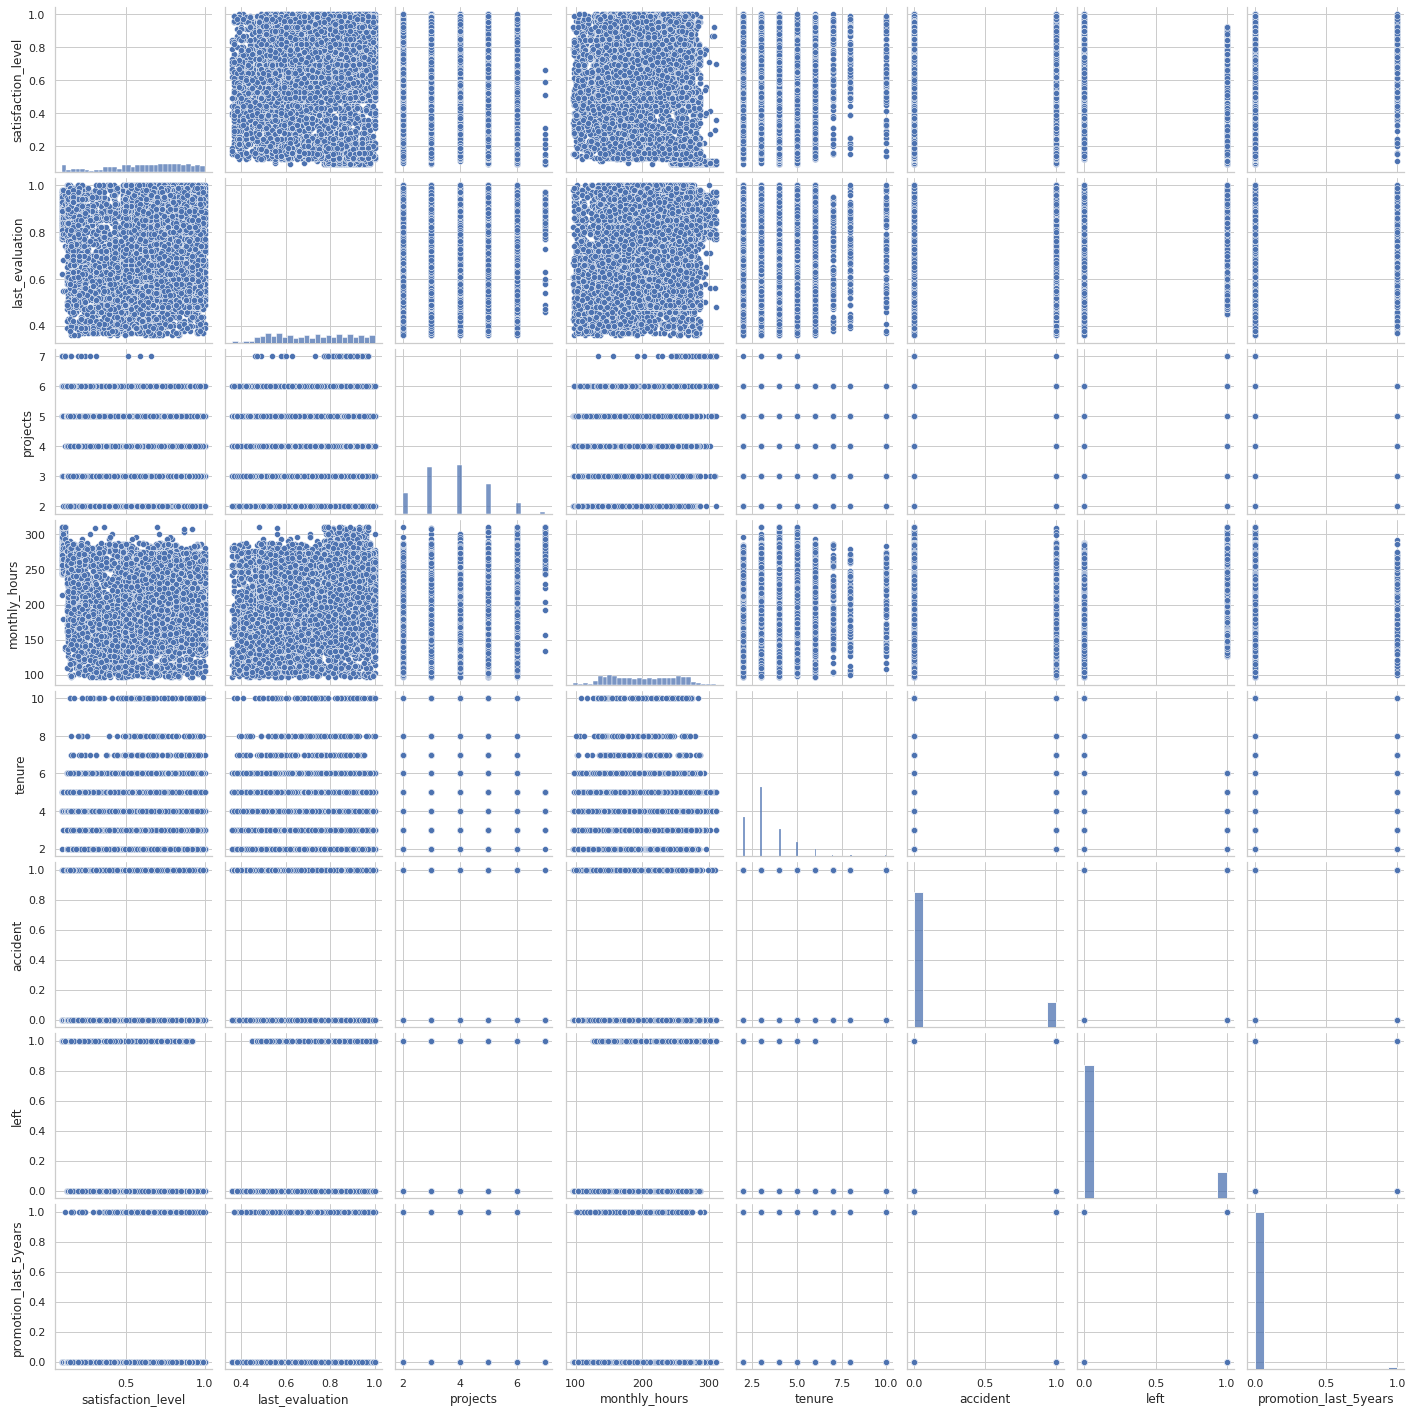

In [33]:
sns.pairplot(df1)

### Insights

- I noticed that there is a possible high correlation between `last_evaluation` and `monthly_hours`. This implies that employees who outperform their peers are often systemaitcally assigned more workloads. While some high-acheiver were satisfied, a large amount had low level of satisfaction of 0.2. 

- Another phenomen is the lack of engagement in under-performing employee who work fewer hours. These could possibly mean that individuals are either misaligned with their work culture, under-assigned, neglected or left without clear direction. This could led to them to quietly disengage and eventually quit. 

- The above two points are also reflected by the number of projects assigned to them, We see that employees who left are either assigned 2 projects or overload with 6 -7. What is alarming that all employees that were assigned 7 projects left the company, with some scoring with a low 0.1 satisfaction level. 

- We also noted where number of projects that shows the safe zone is 3. However, it is impossible to limit projects to 3 per employees. More information such as duration of projects or projects done per year will provide more useful information.

- We also observe that professional stagnation are heavily driving turnout rate. A small number of employees recieved a promotion in the last 5 yeats, suggesting poor career progression. This is worrying as based on previous research we noted that promotion is likely to cut an employee turnouver rate by 80%. Salary is also show to be have negative correlation with turnover rate. 

- We also found that work accident seems to have a proctective factor against turnover. This seems counterintuitive and more data and evidence have to be gather to analyze the reason. Finding the actual reason that could be confounding this relationship could be solution to the high turnover rate. 

- We observe that turnover rate tends to be high during the 3rd to 6th year in the company. Our stakeholders could be more mindful and provide more benefits to retain employees. 

- Lastly, in conclusion, we notice there is a widespread poor working culture, rather than an issue isolated to a single bad manager or department. This is eivdent where all departments faces the same problem. More work have to be done to imporve the work culture to increase retention rate. 


# Moving On 

We will proceed with feature engineering based on our EDA. We then construct, test, and evalaute which model ( Logistic Regression, Naive Bayes, Decision Tree, Random Forest and XGBoost) will be our champion model. This model will be used to predict which employees are more likely to leave. 


# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


In [34]:
# Dataset Splitting & Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler

# Candidate Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB,CategoricalNB, ComplementNB
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Tuning & Cross-Validation
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Evaluation Metrics
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Model Saving
import pickle



🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





# Feature Engineering 

In [35]:
# based on our EDA, we will create two new columns: overworked and loyality
# Feature Engineering Step

df1['overworked'] = ((df1['monthly_hours'] > 250) & (df1['projects'] >= 6)).astype(int)

df1['tenure_risk'] = df1['tenure'].isin([3, 4, 5, 6]).astype(int)

df1.head()

,satisfaction_level,last_evaluation,projects,monthly_hours,tenure,accident,left,promotion_last_5years,department,salary,overworked,tenure_risk
0,0.38,0.53,2,157,3,0,1,0,sales,low,0,1
1,0.80,0.86,5,262,6,0,1,0,sales,medium,0,1
2,0.11,0.88,7,272,4,0,1,0,sales,medium,1,1
3,0.72,0.87,5,223,5,0,1,0,sales,low,0,1
4,0.37,0.52,2,159,3,0,1,0,sales,low,0,1


## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Logisitic Regression


In [36]:
### YOUR CODE HERE ###
per25 = df1["tenure"].quantile(0.25)
per75 = df1["tenure"].quantile(0.75)
IQR = per75 - per25

lowlimit = per25 - 1.5 * IQR
highlimit = per75 + 1.5 * IQR
df_lr0 = df1.copy()
#since LR is senstitive to outliers, we will first drop rows that has outliers. 
# Based on our EDA, tenure is the only column with outliers.
df_lr1 = df_lr0[(df_lr0['tenure'] >= lowlimit) & (df_lr0['tenure'] <= highlimit)]



In [37]:
X_lr = df_lr1.drop(columns=["left"])
y_lr = df_lr1["left"]
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, stratify=y_lr, random_state=42)

In [38]:
num_features = ["satisfaction_level", "last_evaluation", "projects", "monthly_hours", "tenure"]
ord_features = ["salary"]
nom_features = ["department"]

# Define strict scale order for salary mapping
salary_order = ["low", "medium", "high"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("ord", OrdinalEncoder(categories=[salary_order]), ord_features),
        ("nom", OneHotEncoder(drop="first", sparse=False), nom_features)
    ],
    remainder="passthrough" # Keeps accident, promotion, overworked, and tenure_risk as it is
)

# Create the full modeling pipeline
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor_lr", preprocessor),
        ("clf_lr", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

#compared to the examplar version given, this allows for more quick processing and cleaner code. 
#useful to adopt this process for quicker workflow

In [39]:
param_grid = {
    "clf_lr__C": [0.01, 0.1, 1.0, 10.0, 100.0], # for ease, we will use log10 with a range of (-2,3)
    "clf_lr__penalty": ["l2"] # l2 regularization(ridge) -- best use for LR
}

# Setup Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # used because the dataset is highly imbalanced

# Setup GridSearch targeting F1-score
grid_search_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=skf,
    n_jobs=-1, # to maximize processing speed
    refit=True
)

In [40]:
%%time
#fit the model
grid_search_lr.fit(X_train_lr, y_train_lr)

CPU times: user 8.14 s, sys: 8.1 s, total: 16.2 s
Wall time: 21.6 s


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             error_score=nan,
             estimator=Pipeline(memory=None,
                                steps=[('preprocessor_lr',
                                        ColumnTransformer(n_jobs=None,
                                                          remainder='passthrough',
                                                          sparse_threshold=0.3,
                                                          transformer_weights=None,
                                                          transformers=[('num',
                                                                         StandardScaler(copy=True,
                                                                                        with_mean=True,
                                                                                        with_std=True),
                                                                         ['satisfacti

In [41]:
grid_search_lr.best_params_

{'clf_lr__C': 100.0, 'clf_lr__penalty': 'l2'}

In [42]:
grid_search_lr.best_score_

0.4713309034643146

In [43]:
best_lr_model = grid_search_lr.best_estimator_
y_pred = best_lr_model.predict(X_test_lr)
y_pred_proba = best_lr_model.predict_proba(X_test_lr)[:, 1]

In [44]:
print(f"Test Accuracy:  {accuracy_score(y_test_lr, y_pred):.4f}")
print(f"Test Precision: {precision_score(y_test_lr, y_pred):.4f}")
print(f"Test Recall:    {recall_score(y_test_lr, y_pred):.4f}")
print(f"Test F1-Score:  {f1_score(y_test_lr, y_pred):.4f}")
print(f"Test ROC-AUC:   {roc_auc_score(y_test_lr, y_pred_proba):.4f}")

Test Accuracy:  0.8671
Test Precision: 0.6575
Test Recall:    0.4430
Test F1-Score:  0.5293
Test ROC-AUC:   0.8960


In [45]:
print(classification_report(y_test_lr, y_pred, target_names=["Stayed (0)", "Left (1)"]))

              precision    recall  f1-score   support

  Stayed (0)       0.89      0.95      0.92      1857
    Left (1)       0.66      0.44      0.53       377

    accuracy                           0.87      2234
   macro avg       0.78      0.70      0.73      2234
weighted avg       0.85      0.87      0.86      2234



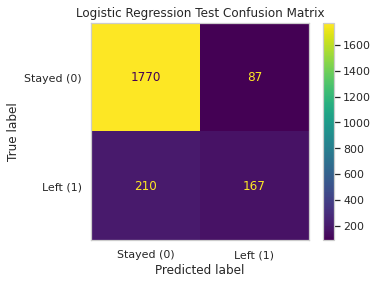

In [46]:
fig, ax = plt.subplots(figsize=(5, 4))

cm = confusion_matrix(y_test_lr, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed (0)", "Left (1)"])

disp.plot(values_format = 'd', ax=ax)

ax.set_title("Logistic Regression Test Confusion Matrix")
plt.grid(False)
plt.show()

We notice that precision and recall and f1 score is way lower compared to other metrics such as accuracy and auc. This one again shows that accuracy is never always the defining metrics, especially in an imbalanced datasets.

However, it does shows that performing 5 fold CV and also feature engineering does contributing towards improving the model. ( simple LR in examplar has a lower score across all metrics except AUC which they did not onclude)

From the confusion matrix, we can observe that other models is able to correctly predicts those who stayed with large difference between TN and FN as compared to those who leave. 

Once again, logistic regression only provides the probability of each class rather than the actual class. The class that LR predicts is based on a threshold (commonly 0.5). In an imbalanced datasets, where the minority class is positive to predict negatives correctly compared to positives.

As such, we will plot a TPR against FPR curve wrt to threshold to find the most optimal threshold value and test it on a new model. 

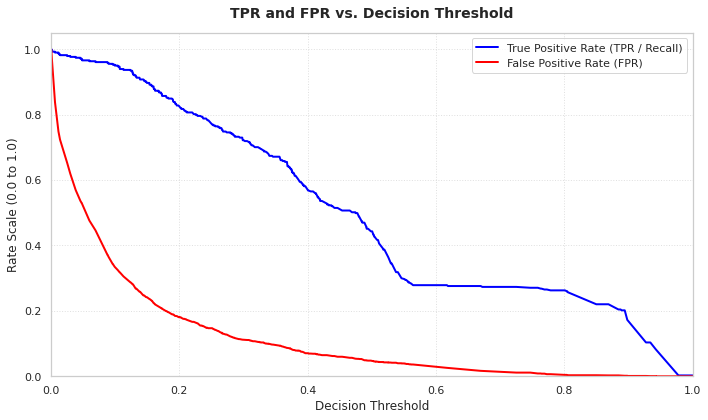

,Threshold,Accuracy,Precision,Recall (TPR),F1-Score,AUC
0,0.1,0.7149,0.3668,0.9496,0.5292,0.896
1,0.2,0.8201,0.4806,0.8223,0.6067,0.896
2,0.3,0.8603,0.5678,0.7215,0.6355,0.896
3,0.4,0.8684,0.6203,0.5676,0.5928,0.896
4,0.5,0.8671,0.6575,0.4430,0.5293,0.896
5,0.6,0.8554,0.6731,0.2785,0.3940,0.896
6,0.7,0.8657,0.7984,0.2732,0.4071,0.896
7,0.8,0.8720,0.9252,0.2626,0.4091,0.896


In [47]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test_lr, y_pred_proba)

# Plot TPR and FPR directly against the Thresholds
plt.figure(figsize=(10, 6))
plt.plot(thresholds, tpr, color='blue', label='True Positive Rate (TPR / Recall)', linewidth=2)
plt.plot(thresholds, fpr, color='red', label='False Positive Rate (FPR)', linewidth=2)


plt.title('TPR and FPR vs. Decision Threshold', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Rate Scale (0.0 to 1.0)', fontsize=12)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc='best', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

threshold_grid = np.arange(0.1, 0.9, 0.1)
table_data = []

for t in threshold_grid:
    y_pred_t = (y_pred_proba >= t).astype(int)
    table_data.append({
        "Threshold": round(t, 2),
        "Accuracy": round(accuracy_score(y_test_lr, y_pred_t), 4),
        "Precision": round(precision_score(y_test_lr, y_pred_t), 4),
        "Recall (TPR)": round(recall_score(y_test_lr, y_pred_t), 4),
        "F1-Score": round(f1_score(y_test_lr, y_pred_t), 4),
        "AUC": round(roc_auc_score(y_test_lr,y_pred_proba),4)
    })

df_metrics_table = pd.DataFrame(table_data)
display(df_metrics_table)

we generally will want our FPR to be as low as possible (less than 0.2) and FPR to be as high a possible ( >= 0.8)

alpha = 0.2 seems to be a strong threshold value. 
From the table, we can see that 0.2 and 0.3 is also a good threshold based on precision,recall and f1 score. 

AUC is the same as AUC does not account for threshold value.

We will want to stick with 0.2 as our threshold values as the main goal of our model is to correctly predict those who will leave. 



In [48]:
threshold_lr = 0.2 

y_test_proba = best_lr_model.predict_proba(X_test_lr)[:, 1]

# Apply threshold: if probability >= 0.2, assign 1 (Left), else 0 (Stayed)
y_pred_custom = (y_test_proba >= threshold_lr).astype(int)


metrics_results = {
    "Accuracy": accuracy_score(y_test_lr, y_pred_custom),
    "Precision": precision_score(y_test_lr, y_pred_custom),
    "Recall (TPR)": recall_score(y_test_lr, y_pred_custom),
    "F1-Score": f1_score(y_test_lr, y_pred_custom),
    "ROC-AUC": roc_auc_score(y_test_lr, y_test_proba),
    "Confusion_Matrix": confusion_matrix(y_test_lr, y_pred_custom)
}

for metric_name, val in metrics_results.items():
    if metric_name != "Confusion_Matrix":
        print(f"{metric_name}: {val:.4f}")

Accuracy: 0.8201
Precision: 0.4806
Recall (TPR): 0.8223
F1-Score: 0.6067
ROC-AUC: 0.8960


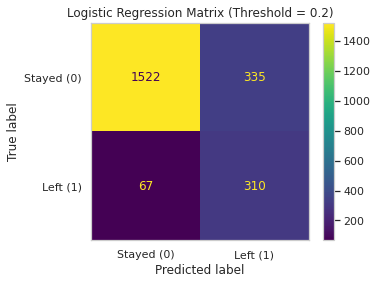

In [49]:
fig, ax = plt.subplots(figsize=(5, 4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=metrics_results["Confusion_Matrix"], 
    display_labels=["Stayed (0)", "Left (1)"]
)
disp.plot( ax=ax, values_format='d')

ax.set_title(f"Logistic Regression Matrix (Threshold = {threshold_lr})")
plt.grid(False)
plt.show()

In [50]:
print(classification_report(y_test_lr, y_pred_custom, target_names=["Stayed (0)", "Left (1)"]))

              precision    recall  f1-score   support

  Stayed (0)       0.96      0.82      0.88      1857
    Left (1)       0.48      0.82      0.61       377

    accuracy                           0.82      2234
   macro avg       0.72      0.82      0.74      2234
weighted avg       0.88      0.82      0.84      2234



We can now see that our model is able to accurately predict those who left as compared to the previous model. This is a huge improvement from our previous model who has a recall of 0.44. 

While the recall of TN has fallen, it is still generally okay as it still has a high value of 0.82 and the model fits our stakeholder needs. 

We now save the model and proceed to the next model, naive Bayes.

In [51]:
lr_20_export = {
    "model_name": "Logistic Regression with Custom Threshold",
    "pipeline": best_lr_model,      
    "threshold": 0.2                # Storing the operational threshold parameter
}

with open("lr_model_custom_threshold.pkl", "wb") as f_lr:
    pickle.dump(lr_20_export, f_lr)

# Naive Bayes

Assumptions
- conditional independence of features
- equal importance of features
- distribution assumptions

1. In reality, it is often difficult to establish conditional independence, Naive Bayes still performed well under practical conditions. However, there is still a need to decide to drop the original features that were to make new features, or engineered features. To ensure that the model has granular access to all features, such as continuous features than categorical variable, we will keeep all original features. 
2. For distribution assumption, Naive Bayes typically accept only numerical or categorical features. In our model, we will work with a mixed Naive Bayes. Categorical variable will undergo one hot encoding or ordinal encoding. 

In [52]:
df_nb = df1.drop(columns = ["overworked","tenure_risk"])

In [53]:
X_nb = df_nb.drop(columns = ['left'])
y_nb = df_nb['left']

In [54]:
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X_nb, y_nb, test_size=0.2, stratify=y_nb, random_state=42)

In [55]:
num_features = ["satisfaction_level", "last_evaluation", "monthly_hours", "tenure", "projects"]
nom_features = ["department"]
ord_features = ["salary"]
salary_order = ["low", "medium", "high"]



preprocessor_nb = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features), #  ensure numerical values
        ("ord", OrdinalEncoder(categories=[salary_order]), ord_features),
        ("nom", OneHotEncoder(drop=None, sparse=False), nom_features),
    ], #scaling is not neccessary for NB models
    remainder="passthrough" # Keeps 'accident' and 'promotion_last_5years'
)

nb_pipeline = Pipeline(
    steps=[
        ("preprocessor_nb", preprocessor_nb),
        ("clf_nb", GaussianNB())
    ]
)

param_grid_nb = {
    "clf_nb__var_smoothing": np.logspace(0, -9, num=10) # using logs value to decrease computational
}

skf_nb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_nb = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=param_grid_nb,
    scoring="f1",
    cv=skf_nb,
    n_jobs=-1,
    refit=True
)

In [56]:
%%time
grid_search_nb.fit(X_train_nb, y_train_nb)

CPU times: user 275 ms, sys: 32.7 ms, total: 308 ms
Wall time: 2.61 s


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             error_score=nan,
             estimator=Pipeline(memory=None,
                                steps=[('preprocessor_nb',
                                        ColumnTransformer(n_jobs=None,
                                                          remainder='passthrough',
                                                          sparse_threshold=0.3,
                                                          transformer_weights=None,
                                                          transformers=[('num',
                                                                         'passthrough',
                                                                         ['satisfaction_level',
                                                                          'last_evaluation',
                                                                          'monthly_hours',
                        

In [57]:
best_nb_model = grid_search_nb.best_estimator_
y_pred_nb = best_nb_model.predict(X_test_nb)
y_pred_proba_nb = best_nb_model.predict_proba(X_test_nb)[:, 1]

In [58]:
grid_search_nb.best_params_

{'clf_nb__var_smoothing': 1e-06}

In [59]:
grid_search_nb.best_score_

0.5577716463458953

In [60]:
print(f"Test Accuracy:  {accuracy_score(y_test_nb, y_pred_nb):.4f}")
print(f"Test Precision: {precision_score(y_test_nb, y_pred_nb):.4f}")
print(f"Test Recall:    {recall_score(y_test_nb, y_pred_nb):.4f}")
print(f"Test F1-Score:  {f1_score(y_test_nb, y_pred_nb):.4f}")
print(f"Test ROC-AUC:   {roc_auc_score(y_test_nb, y_pred_proba_nb):.4f}\n")

Test Accuracy:  0.8587
Test Precision: 0.5608
Test Recall:    0.6834
Test F1-Score:  0.6161
Test ROC-AUC:   0.8411



In [61]:
print(classification_report(y_test_nb, y_pred_nb, target_names=["Stayed (0)", "Left (1)"]))

              precision    recall  f1-score   support

  Stayed (0)       0.93      0.89      0.91      2001
    Left (1)       0.56      0.68      0.62       398

    accuracy                           0.86      2399
   macro avg       0.75      0.79      0.76      2399
weighted avg       0.87      0.86      0.86      2399



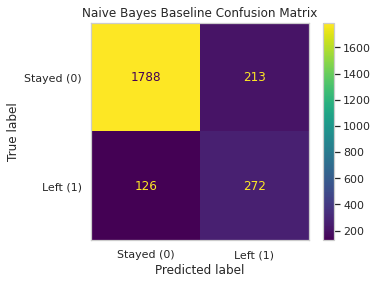

In [62]:
fig, ax = plt.subplots(figsize=(5, 4))
cm_nb = confusion_matrix(y_test_nb, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=["Stayed (0)", "Left (1)"])
disp_nb.plot(values_format='d', ax=ax)
ax.set_title("Naive Bayes Baseline Confusion Matrix")
plt.grid(False)
plt.show()

Generally, we see that Naive Bayes Model perform better then the intial LR with a higher recal for those who left and a higher F1 score. This is also support by the confusion matrix which has predicted more than two-third of the Left(1).  However, we do note that it has a lower AUC value. 

To improve our version, an alternative model that we can use will be ComplementNB. This is because it calculates probs based on the complement of other class, making it more robust against imbalanced datasets.


In [63]:
nb_pipeline_com = Pipeline(
    steps=[
        ("preprocessor_nb", preprocessor_nb),
        # Swap GaussianNB out for ComplementNB
        ("clf_nb_com", ComplementNB()) 
    ]
)

param_grid_nb_com = {
    "clf_nb_com__alpha": np.logspace(-5, -7, num=10),
    # Test letting data dictate priors vs. forcing a balanced 50/50 lens
    "clf_nb_com__fit_prior": [None, [0.5, 0.5], [0.6, 0.4]] 
}
skf_nb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_nb_com = GridSearchCV(
    estimator=nb_pipeline_com,
    param_grid=param_grid_nb_com,
    scoring="f1",
    cv=skf_nb,
    n_jobs=-1,
    refit=True
)

In [64]:
%%time
grid_search_nb_com.fit(X_train_nb, y_train_nb)

CPU times: user 568 ms, sys: 42.8 ms, total: 611 ms
Wall time: 2.08 s


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             error_score=nan,
             estimator=Pipeline(memory=None,
                                steps=[('preprocessor_nb',
                                        ColumnTransformer(n_jobs=None,
                                                          remainder='passthrough',
                                                          sparse_threshold=0.3,
                                                          transformer_weights=None,
                                                          transformers=[('num',
                                                                         'passthrough',
                                                                         ['satisfaction_level',
                                                                          'last_evaluation',
                                                                          'monthly_hours',
                        

In [65]:
best_nb_model_com = grid_search_nb_com.best_estimator_
y_pred_nb_com = best_nb_model_com.predict(X_test_nb)
y_pred_proba_nb_com = best_nb_model_com.predict_proba(X_test_nb)[:, 1]

In [66]:
grid_search_nb_com.best_params_

{'clf_nb_com__alpha': 1e-05, 'clf_nb_com__fit_prior': None}

In [67]:
grid_search_nb_com.best_score_

0.3891751050814487

In [68]:
print(f"Test Accuracy:  {accuracy_score(y_test_nb, y_pred_nb_com):.4f}")
print(f"Test Precision: {precision_score(y_test_nb, y_pred_nb_com):.4f}")
print(f"Test Recall:    {recall_score(y_test_nb, y_pred_nb_com):.4f}")
print(f"Test F1-Score:  {f1_score(y_test_nb, y_pred_nb_com):.4f}")
print(f"Test ROC-AUC:   {roc_auc_score(y_test_nb, y_pred_proba_nb_com):.4f}\n")

Test Accuracy:  0.6082
Test Precision: 0.2532
Test Recall:    0.6985
Test F1-Score:  0.3717
Test ROC-AUC:   0.7480



In [69]:
print(classification_report(y_test_nb, y_pred_nb_com, target_names=["Stayed (0)", "Left (1)"]))

              precision    recall  f1-score   support

  Stayed (0)       0.91      0.59      0.72      2001
    Left (1)       0.25      0.70      0.37       398

    accuracy                           0.61      2399
   macro avg       0.58      0.64      0.54      2399
weighted avg       0.80      0.61      0.66      2399



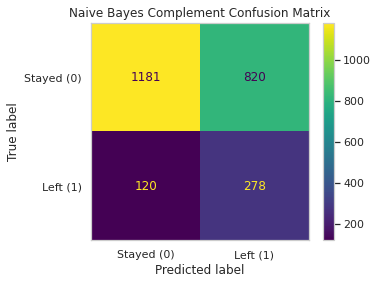

In [70]:
fig, ax = plt.subplots(figsize=(5, 4))
cm_nb = confusion_matrix(y_test_nb, y_pred_nb_com)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=["Stayed (0)", "Left (1)"])
disp_nb.plot(values_format='d', ax=ax)
ax.set_title("Naive Bayes Complement Confusion Matrix")
plt.grid(False)
plt.show()

While ComplementNB is engineered to tackle imbalanced datasets by allocating the weight from the complement class (in this class, the majority class for the minority class), it heavily flags out anything factor that deviates from the original majority class, assigning it as positive. Thus, we observe that there are suddenly more false positives compared to the previous model. This make the model very sensitive to small difference, especially when the datasets contain mutiple features/reasons that could potential contribute to staying. 


In the case, we will stick to the original NB model.

In [71]:
with open("nb_model_baseline.pkl", "wb") as f_nb:
    pickle.dump(best_nb_model, f_nb)

# Decision Tree

Decision tree tends handle the assumptions of Logisitic Regression and Naive Bayes model well. Thus, in this section, we keep all features to explore which provide the most infomation gain/entropy reduction or strong spltting points. 

In [72]:
df_dt = df1.copy()

In [73]:
X_dt = df1.drop(columns=["left"])
y_dt = df1["left"]

In [74]:
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_dt, y_dt, test_size=0.2, stratify=y_dt, random_state=42)

In [75]:
num_features = ["satisfaction_level", "last_evaluation", "projects", "monthly_hours", "tenure"]
ord_features = ["salary"]
nom_features = ["department"]
salary_order = ["low", "medium", "high"]

preprocessor_dt = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("ord", OrdinalEncoder(categories=[salary_order]), ord_features),
        ("nom", OneHotEncoder(drop="first", sparse=False), nom_features)
    ],
    remainder="passthrough" # Keeps overworked, tenure_risk, and accident
)

dt_pipeline = Pipeline(steps=[
    ("preprocessor_dt", preprocessor_dt),
    ("clf_dt", DecisionTreeClassifier(random_state=42))
])

In [76]:
param_grid_dt = {
    "clf_dt__criterion": ["gini", "information gain"],
    "clf_dt__max_depth": [4, 6, 8, 10, None],
    "clf_dt__min_samples_leaf": [2, 5, 10, 20],
    "clf_dt__class_weight": ["balanced", None] # 'balanced' helo with class imbalance
}

skf_dt = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_dt = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid_dt,
    scoring="f1",
    cv=skf_dt,
    n_jobs=-1,
    refit=True
)

In [79]:
%%time
grid_search_dt.fit(X_train_dt,y_train_dt)

CPU times: user 1.71 s, sys: 133 ms, total: 1.84 s
Wall time: 6.84 s


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             error_score=nan,
             estimator=Pipeline(memory=None,
                                steps=[('preprocessor_dt',
                                        ColumnTransformer(n_jobs=None,
                                                          remainder='passthrough',
                                                          sparse_threshold=0.3,
                                                          transformer_weights=None,
                                                          transformers=[('num',
                                                                         'passthrough',
                                                                         ['satisfaction_level',
                                                                          'last_evaluation',
                                                                          'projects',
                             

In [80]:
grid_search_dt.best_params_

{'clf_dt__class_weight': None,
 'clf_dt__criterion': 'gini',
 'clf_dt__max_depth': 6,
 'clf_dt__min_samples_leaf': 2}

In [81]:
grid_search_dt.best_score_

0.9422345874625035

In [82]:
best_dt_model = grid_search_dt.best_estimator_
y_pred_dt = best_dt_model.predict(X_test_dt)
y_pred_proba_dt = best_dt_model.predict_proba(X_test_dt)[:, 1]

In [84]:
print(f"Test Accuracy:  {accuracy_score(y_test_dt, y_pred_dt):.4f}")
print(f"Test Precision: {precision_score(y_test_dt, y_pred_dt):.4f}")
print(f"Test Recall:    {recall_score(y_test_dt, y_pred_dt):.4f}")
print(f"Test F1-Score:  {f1_score(y_test_dt, y_pred_dt):.4f}")
print(f"Test ROC-AUC:   {roc_auc_score(y_test_dt, y_pred_proba_dt):.4f}\n")

Test Accuracy:  0.9846
Test Precision: 0.9763
Test Recall:    0.9296
Test F1-Score:  0.9524
Test ROC-AUC:   0.9748



In [85]:
print(classification_report(y_test_dt, y_pred_dt, target_names=["Stayed (0)", "Left (1)"]))

              precision    recall  f1-score   support

  Stayed (0)       0.99      1.00      0.99      2001
    Left (1)       0.98      0.93      0.95       398

    accuracy                           0.98      2399
   macro avg       0.98      0.96      0.97      2399
weighted avg       0.98      0.98      0.98      2399



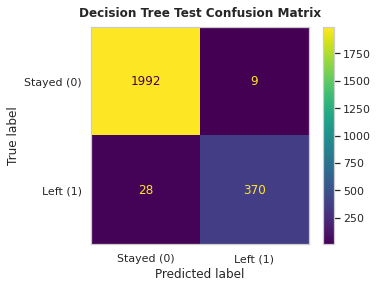

In [87]:
cm_dt = confusion_matrix(y_test_dt, y_pred_dt)

fig, ax = plt.subplots(figsize=(5, 4))
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=["Stayed (0)", "Left (1)"])
disp_dt.plot(values_format='d', ax=ax)

ax.set_title("Decision Tree Test Confusion Matrix", fontsize=12, fontweight="bold", pad=10)
plt.grid(False)
plt.show()

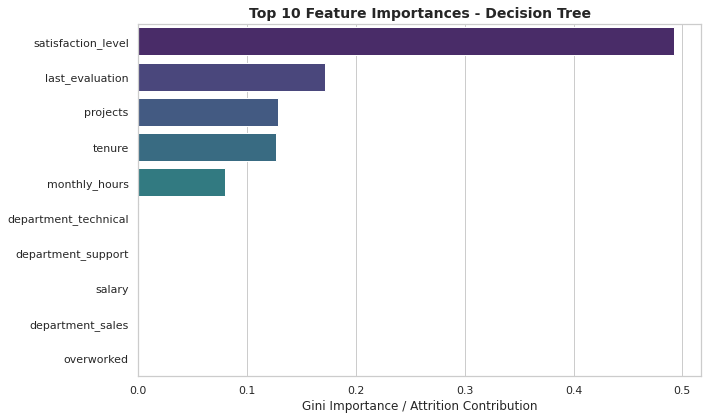

In [89]:
encoded_nom_features = list(best_dt_model.named_steps['preprocessor_dt'].transformers_[2][1].get_feature_names(nom_features))
all_feature_names = num_features + ord_features + encoded_nom_features + ['accident', 'promotion_last_5years', 'overworked', 'tenure_risk']

importances = best_dt_model.named_steps['clf_dt'].feature_importances_
dt_importances = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=dt_importances.values[:10], y=dt_importances.index[:10], palette="viridis")
plt.title("Top 10 Feature Importances - Decision Tree", fontsize=14, fontweight="bold")
plt.xlabel("Gini Importance / Attrition Contribution")
plt.tight_layout()
plt.show()

In [90]:
dt_export = {
    "model_name": "Tuned Decision Tree Classifier",
    "pipeline": best_dt_model,
    "best_parameters": grid_search_dt.best_params_
}

with open("dt_model_tuned.pkl", "wb") as f_dt:
    pickle.dump(dt_export, f_dt)

We observe that Decision Tree generally perform better than the other 2 models. This is mainly due to data being non-linear which contradicts the main assumption of LR and NB of a linear relationship. This is also evident in our EDA where most features either have a bimodal or mulitmodal distribution. 

Based on the confusion matrix, we can observe that our model has a very high precision and recall for predicting those who will leave. The same also applies for those who stay. 

We also noted that the most important features is satisfaction_level, which is quite expected as it mainly groups all the dissatifaction from our features such as projects, and monthly hours. 

Overall, the DT models performs really well across all metrics. This strategically captures the requirements of our stakeholder.

However, it is neccessary to remind ourselves that Decision Tree is often prone to overfitting due to it high variance, which can easily be affected by random noise.

As such, we will proceed via ensembling methods with decision tree via bagging and boosting to reduce the bias-variance trade-off. 

# Random Forest (Bagging)

Recap (new concept from dsa1101): Random forest (bootstrap aggregating) works via building an forest of DT. Each DT is trained on a random bootstrap sample of data (w/ replacement). This mean that 63.2% of the training data is not covering by a DT. It reduces variance by averaging out the predictions of uncorrelated trees. 

In [91]:
df_rf = df1.copy()

In [92]:
X_rf = df1.drop(columns=["left"])
y_rf = df1["left"]

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, stratify=y_rf, random_state=42)

In [93]:
num_features = ["satisfaction_level", "last_evaluation", "projects", "monthly_hours", "tenure"]
ord_features = ["salary"]
nom_features = ["department"]
salary_order = ["low", "medium", "high"]

preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("ord", OrdinalEncoder(categories=[salary_order]), ord_features),
        ("nom", OneHotEncoder(drop="first", sparse=False), nom_features)
    ],
    remainder="passthrough" # Keeps overworked, tenure_risk, and accident
)

rf_pipeline = Pipeline(steps=[
    ("preprocessor_rf", preprocessor_rf),
    ("clf_rf", RandomForestClassifier(random_state=42))
])

In [94]:
param_grid_rf = {
    'clf_rf__max_depth': [3, 5, None], 
    'clf_rf__max_features': [1.0],
    'clf_rf__max_samples': [0.7, 1.0],
    'clf_rf__min_samples_leaf': [1, 2, 3],
    'clf_rf__min_samples_split': [2, 3, 4],
    'clf_rf__n_estimators': [300, 500],
}

# 5-Fold Stratified CV
skf_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    scoring="f1",
    cv=skf_rf,
    n_jobs=-1,
    refit=True
)

In [95]:
%%time
grid_search_rf.fit(X_train_rf, y_train_rf)

CPU times: user 8.49 s, sys: 620 ms, total: 9.11 s
Wall time: 10min 22s


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             error_score=nan,
             estimator=Pipeline(memory=None,
                                steps=[('preprocessor_rf',
                                        ColumnTransformer(n_jobs=None,
                                                          remainder='passthrough',
                                                          sparse_threshold=0.3,
                                                          transformer_weights=None,
                                                          transformers=[('num',
                                                                         'passthrough',
                                                                         ['satisfaction_level',
                                                                          'last_evaluation',
                                                                          'projects',
                             

In [96]:
grid_search_rf.best_params_

{'clf_rf__max_depth': None,
 'clf_rf__max_features': 1.0,
 'clf_rf__max_samples': 0.7,
 'clf_rf__min_samples_leaf': 1,
 'clf_rf__min_samples_split': 4,
 'clf_rf__n_estimators': 300}

In [97]:
grid_search_rf.best_score_

0.9489331365804394

In [98]:
best_rf_model = grid_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test_rf)
y_pred_proba_rf = best_rf_model.predict_proba(X_test_rf)[:, 1]

In [99]:
print(f"Test Accuracy:  {accuracy_score(y_test_rf, y_pred_rf):.4f}")
print(f"Test Precision: {precision_score(y_test_rf, y_pred_rf):.4f}")
print(f"Test Recall:    {recall_score(y_test_rf, y_pred_rf):.4f}")
print(f"Test F1-Score:  {f1_score(y_test_rf, y_pred_rf):.4f}")
print(f"Test ROC-AUC:   {roc_auc_score(y_test_rf, y_pred_proba_rf):.4f}\n")

Test Accuracy:  0.9858
Test Precision: 0.9866
Test Recall:    0.9271
Test F1-Score:  0.9560
Test ROC-AUC:   0.9771



In [100]:
print(classification_report(y_test_rf, y_pred_rf, target_names=["Stayed (0)", "Left (1)"]))

              precision    recall  f1-score   support

  Stayed (0)       0.99      1.00      0.99      2001
    Left (1)       0.99      0.93      0.96       398

    accuracy                           0.99      2399
   macro avg       0.99      0.96      0.97      2399
weighted avg       0.99      0.99      0.99      2399



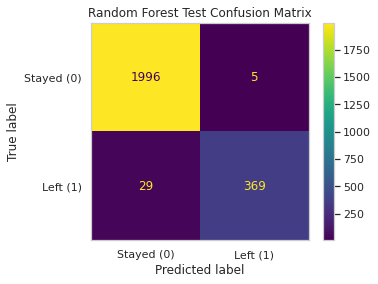

In [102]:
fig, ax = plt.subplots(figsize=(5, 4))
cm_rf = confusion_matrix(y_test_rf, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Stayed (0)", "Left (1)"])
disp_rf.plot(values_format='d', ax=ax)

ax.set_title("Random Forest Test Confusion Matrix")
plt.grid(False)
plt.show()

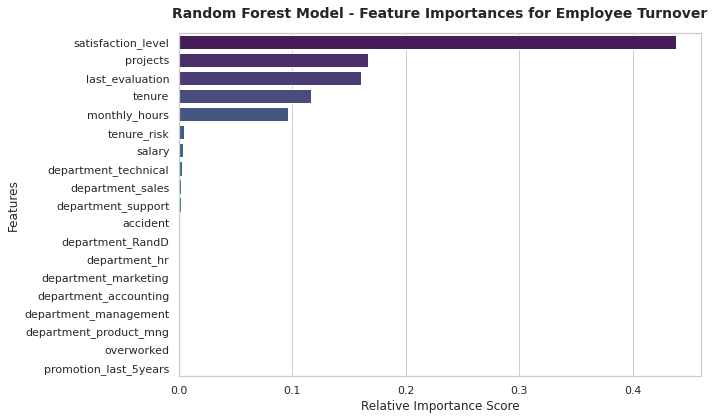

In [108]:
encoded_nom_features = list(
    best_rf_model.named_steps['preprocessor_rf']
    .transformers_[2][1]
    .get_feature_names(nom_features)
)

all_feature_names = num_features + ord_features + encoded_nom_features + ['accident', 'promotion_last_5years', 'overworked', 'tenure_risk']

cleaned_feature_names = [name.split('__')[-1] for name in all_feature_names]

importances = best_rf_model.named_steps['clf_rf'].feature_importances_

df_importance = pd.DataFrame({
    'Feature': cleaned_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest Model - Feature Importances for Employee Turnover', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

Overall,we notice that our random forest perform slightly better than our single decision tree, though the recall for TP is slightly off by 1. This also suggest that the initial DT was prune pretty well, with a relatively low variance. 

Furthermore, we also notice that there are more features shown in the importance graph. This is generally because of how RF works by using random features sampling, where more important features are not chosen, giving other variables more chances for RF algorithm selection. 

In [ ]:
model_filename = "salifort_random_forest_model.pkl"

with open(model_filename, "wb") as file:
    pickle.dump(best_rf_model, file)

# XGBoost

Notes(recap): XGBoost is a type of boosting method under same ensembles method as RF. However, it performs differently as RF. RF works in parallel, while boosting models work via building models sequentially. Each new model is trained to correct the residual errors from the previous model. This helps to reduce mainly the bias, tackling the bias-variance issues. 

In [109]:
df_xgb = df1.copy()

In [110]:
X_xgb = df_xgb.drop(columns=["left"])
y_xgb = df_xgb["left"]

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2, stratify=y_xgb, random_state=42)

In [111]:
num_features = ["satisfaction_level", "last_evaluation", "projects", "monthly_hours", "tenure"]
ord_features = ["salary"]
nom_features = ["department"]
salary_order = ["low", "medium", "high"]

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("ord", OrdinalEncoder(categories=[salary_order]), ord_features),
        ("nom", OneHotEncoder(drop="first", sparse=False), nom_features)
    ],
    remainder="passthrough" # Keeps overworked, tenure_risk, and accident
)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor_xgb", preprocessor_xgb),
        ("clf_xgb", XGBClassifier(eval_metric="logloss", random_state=42))
    ]
)

In [118]:
param_grid_xgb = {
    "clf_xgb__max_depth": [4, 6],
    "clf_xgb__min_child_weight": [1, 3, 5],
    "clf_xgb__learning_rate": [ 0.1, 0.2],
    "clf_xgb__n_estimators": [200, 300]
}

skf_xgb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    scoring="f1",
    cv=skf_xgb,
    n_jobs=-1,
    refit=True
)

In [119]:
%%time
# Fit the XGBoost configuration
grid_search_xgb.fit(X_train_xgb, y_train_xgb)

CPU times: user 7min 15s, sys: 1.25 s, total: 7min 16s
Wall time: 7min 4s


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             error_score=nan,
             estimator=Pipeline(memory=None,
                                steps=[('preprocessor_xgb',
                                        ColumnTransformer(n_jobs=None,
                                                          remainder='passthrough',
                                                          sparse_threshold=0.3,
                                                          transformer_weights=None,
                                                          transformers=[('num',
                                                                         'passthrough',
                                                                         ['satisfaction_level',
                                                                          'last_evaluation',
                                                                          'projects',
                            

In [120]:
grid_search_xgb.best_params_

{'clf_xgb__learning_rate': 0.1,
 'clf_xgb__max_depth': 6,
 'clf_xgb__min_child_weight': 1,
 'clf_xgb__n_estimators': 200}

In [121]:
grid_search_xgb.best_score_

0.945715755184788

In [122]:
best_xgb_model = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test_xgb)
y_pred_proba_xgb = best_xgb_model.predict_proba(X_test_xgb)[:, 1]

In [123]:
print(f"Test Accuracy:  {accuracy_score(y_test_xgb, y_pred_xgb):.4f}")
print(f"Test Precision: {precision_score(y_test_xgb, y_pred_xgb):.4f}")
print(f"Test Recall:    {recall_score(y_test_xgb, y_pred_xgb):.4f}")
print(f"Test F1-Score:  {f1_score(y_test_xgb, y_pred_xgb):.4f}")
print(f"Test ROC-AUC:   {roc_auc_score(y_test_xgb, y_pred_proba_xgb):.4f}\n")

Test Accuracy:  0.9837
Test Precision: 0.9711
Test Recall:    0.9296
Test F1-Score:  0.9499
Test ROC-AUC:   0.9832



In [124]:
print(classification_report(y_test_xgb, y_pred_xgb, target_names=["Stayed (0)", "Left (1)"]))

              precision    recall  f1-score   support

  Stayed (0)       0.99      0.99      0.99      2001
    Left (1)       0.97      0.93      0.95       398

    accuracy                           0.98      2399
   macro avg       0.98      0.96      0.97      2399
weighted avg       0.98      0.98      0.98      2399



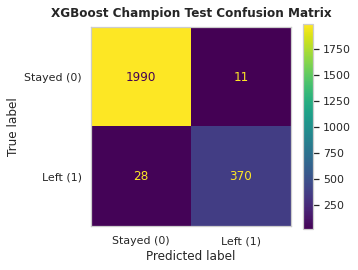

In [126]:
cm_xgb = confusion_matrix(y_test_xgb, y_pred_xgb)

fig, ax = plt.subplots(figsize=(5, 4))
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["Stayed (0)", "Left (1)"])
disp_xgb.plot(values_format='d', ax=ax)

ax.set_title("XGBoost Champion Test Confusion Matrix", fontsize=12, fontweight='bold', pad=10)
plt.grid(False)
plt.tight_layout()
plt.show()

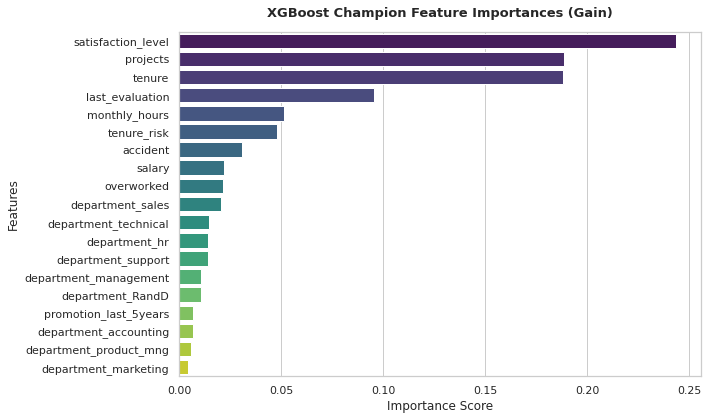

In [132]:
preprocessor_obj = best_xgb_model.named_steps['preprocessor_xgb']

num_features_list = num_features  # Continuous columns
ord_feature_names = ord_features  # Salary column

ohe_feature_names = preprocessor_obj.named_transformers_['nom'].get_feature_names(nom_features).tolist()

explicit_cols = num_features + ord_features + nom_features
remainder_cols = [col for col in X_xgb.columns if col not in explicit_cols]

all_features_encoded = num_features_list + ord_feature_names + ohe_feature_names + remainder_cols

xgb_clf = best_xgb_model.named_steps['clf_xgb']
importances = xgb_clf.feature_importances_

df_importances = pd.DataFrame({
    'Feature': all_features_encoded,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importances, x='Importance', y='Feature', palette='viridis')
plt.title('XGBoost Champion Feature Importances (Gain)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()



We can see that our XGBoost performs around the same as our RF and DT model. In fact, it has the same recall value as DT model as seen in the CM

In [135]:
with open("xgb_model_baseline.pkl", "wb") as f_xgb:
    pickle.dump(best_xgb_model, f_xgb)

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



# Conclusion

we shall now compared all 5 models

In [140]:
def get_row_metrics(model_name, y_true, y_pred, y_prob):
    return {
        "Model": model_name,
        "Test Accuracy": accuracy_score(y_true, y_pred),
        "Test Precision": precision_score(y_true, y_pred),
        "Test Recall (TPR)": recall_score(y_true, y_pred),
        "Test F1-Score": f1_score(y_true, y_pred),
        "Test ROC-AUC": roc_auc_score(y_true, y_prob)
    }

compiled_metrics = [
    get_row_metrics("Logistic Regression (Threshold = 0.5)", y_test_lr, y_pred, y_pred_proba),
    get_row_metrics("Logistic Regression (Custom Threshold = 0.2)", y_test_lr, y_pred_custom, y_test_proba),
    get_row_metrics("Naive Bayes (Gaussian Baseline)", y_test_nb, y_pred_nb, y_pred_proba_nb),
    get_row_metrics("Decision Tree (Tuned)", y_test_dt, y_pred_dt, y_pred_proba_dt),
    get_row_metrics("Random Forest (Tuned)", y_test_dt, y_pred_rf, y_pred_proba_rf),
    get_row_metrics("XGBoost (Tuned)", y_test_dt, y_pred_xgb, y_pred_proba_xgb)
]

df_comparison = pd.DataFrame(compiled_metrics)

print("### Salifort Motors - Final Model Comparison Table ###\n")
display(
    df_comparison.style
    .highlight_max(subset=["Test Accuracy", "Test Precision", "Test Recall (TPR)", "Test F1-Score", "Test ROC-AUC"], color="lightgreen")
    .format({
        "Test Accuracy": "{:.4f}",
        "Test Precision": "{:.4f}",
        "Test Recall (TPR)": "{:.4f}",
        "Test F1-Score": "{:.4f}",
        "Test ROC-AUC": "{:.4f}"
    })
    .hide_index()
)

### Salifort Motors - Final Model Comparison Table ###



Model,Test Accuracy,Test Precision,Test Recall (TPR),Test F1-Score,Test ROC-AUC
Logistic Regression (Threshold = 0.5),0.8671,0.6575,0.4430,0.5293,0.8960
Logistic Regression (Custom Threshold = 0.2),0.8201,0.4806,0.8223,0.6067,0.8960
Naive Bayes (Gaussian Baseline),0.8587,0.5608,0.6834,0.6161,0.8411
Decision Tree (Tuned),0.9846,0.9763,0.9296,0.9524,0.9748
Random Forest (Tuned),0.9858,0.9866,0.9271,0.9560,0.9771
XGBoost (Tuned),0.9837,0.9711,0.9296,0.9499,0.9832


In conclusion, while Random Forest underperformed Decision Tree in terms of recall, it is of negligible difference. Random Forest performed best in Acc, Precision and F1 score. It also scored the second highest in AUC. Thus, we will use RF as our champion model. 

✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



Read the readme.md for more details. 

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

[Double-click to enter your summary here.]

### Conclusion, Recommendations, Next Steps

[Double-click to enter your conclusion, recommendations, and next steps here.]

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.